# Exploración de vacantes para la predicción de rangos salariales

En este notebook analizamos las ofertas de las vacantes publicadas en Foorilla Hiring. El propósito es establecer si la información disponible permite estimar dos resultados anuales en dólares estadounidenses: el salario mínimo (`Y1`) y el salario máximo (`Y2`) ofrecidos para una posición.

La unidad de análisis es cada vacante publicada. Cuando la oferta informa sus límites salariales, los tratamos como valores observados; cuando uno o ambos límites no aparecen, conservamos la estimación suministrada por Foorilla y registramos su procedencia. Esta diferencia es fundamental para interpretar los resultados y definir posteriormente el alcance del modelo.

## 0. Alcance y recorrido del análisis

Para desarrollar el análisis, partimos de la integración de los diferentes cortes de información disponibles, revisando inicialmente la calidad de los datos y la procedencia de las variables objetivo Y1 y Y2. A partir de esta base, realizamos una exploración de las principales variables que pueden explicar el comportamiento del mercado laboral, considerando aspectos como la demanda de vacantes, los salarios, la experiencia requerida, la modalidad de trabajo, las áreas o cargos, las habilidades solicitadas, la ubicación geográfica y el tipo de empresa o publicador. Este recorrido nos permite no solo entender cómo está compuesta la información y qué patrones se presentan en los datos, sino también identificar cuáles variables tienen mayor potencial para ser utilizadas posteriormente en el modelo. Finalmente, con los hallazgos obtenidos definimos los criterios para construir una muestra adecuada, establecer las variables que se incluirán o excluirán y plantear una estrategia de evaluación que reduzca posibles fugas de información y permita medir de forma más realista el desempeño del modelo.

## 1. Preparación del entorno de análisis

En esta sección configuramos las librerías, la tipografía y el estilo visual que utilizaremos en todo el análisis. Las gráficas se generan con **Droid Serif**, una escala de azules y fondo blanco para conservar la misma presentación del informe. También localizamos automáticamente todos los archivos `data/jobs_*.csv`, de manera que un nuevo corte pueda incorporarse sin cambiar el código.

In [2]:
from pathlib import Path
from urllib.parse import urldefrag
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FILES = sorted((ROOT/'data').glob('jobs_*.csv'))
if not FILES:
    raise FileNotFoundError('No se encontraron archivos data/jobs_*.csv')
for font_path in sorted((ROOT/'assets/fonts').glob('DroidSerif-*.ttf')):
    font_manager.fontManager.addfont(font_path)
plt.rcParams.update({'font.family':'Droid Serif','font.size':9,'axes.titlesize':11,
                     'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8,
                     'figure.facecolor':'white','axes.facecolor':'white'})
sns.set_theme(style='white', font='Droid Serif')
BLUE_DARK='#08306B'; BLUE='#2171B5'; BLUE_MID='#6BAED6'; BLUE_LIGHT='#C6DBEF'
def clean_ax(ax):
    ax.grid(False); ax.spines[['top','right']].set_visible(False)
pd.set_option('display.max_columns',50)
[p.name for p in FILES]

['jobs_2026-08-16.csv', 'jobs_2026-08-17.csv', 'jobs_2026-08-20.csv']

## 2. Integración de los cortes disponibles

Revisamos el volumen, las fechas y la cantidad de identificadores de cada archivo antes de unirlos. Cuando un mismo `id` aparece más de una vez, conservamos primero la versión del corte más reciente; si todavía existe empate, elegimos la fila con mayor cantidad de información y la fecha de publicación más nueva. Con esta regla evitamos contar como observaciones distintas las actualizaciones de una misma vacante.

In [3]:
parts=[]; inventory=[]
for priority,path in enumerate(FILES):
    x=pd.read_csv(path,low_memory=False)
    inventory.append({'archivo':path.name,'filas':len(x),'id_unicos':x.id.nunique(),
                      'duplicados_internos':len(x)-x.id.nunique(),
                      'fecha_min':pd.to_datetime(x.published,errors='coerce').min(),
                      'fecha_max':pd.to_datetime(x.published,errors='coerce').max()})
    x['_source_file']=path.name; x['_source_priority']=priority; parts.append(x)
raw=pd.concat(parts,ignore_index=True)
raw['published']=pd.to_datetime(raw.published,errors='coerce',utc=True)
raw['_completeness']=raw.drop(columns=['_source_file','_source_priority']).notna().sum(axis=1)
by_id=(raw.sort_values(['id','_source_priority','_completeness','published'],ascending=[True,False,False,False])
          .drop_duplicates('id',keep='first').copy())
display(pd.DataFrame(inventory))
pd.Series({'filas_integradas':len(raw),'id_unicos':len(by_id),
           'filas_repetidas_por_id':len(raw)-len(by_id),
           'fecha_min':by_id.published.min(),'fecha_max':by_id.published.max(),
           'variables_originales':len([c for c in raw.columns if not c.startswith('_')])})

,archivo,filas,id_unicos,duplicados_internos,fecha_min,fecha_max
0,jobs_2026-08-16.csv,326311,326299,12,2025-01-01 00:00:00+00:00,2026-08-15 18:02:21+00:00
1,jobs_2026-08-17.csv,180,180,0,2026-08-15 00:22:42+00:00,2026-08-17 10:51:14+00:00
2,jobs_2026-08-20.csv,2799,2799,0,2026-08-15 00:22:42+00:00,2026-08-20 20:10:47+00:00


filas_integradas                             329290
id_unicos                                    329062
filas_repetidas_por_id                          228
fecha_min                 2025-01-01 00:00:00+00:00
fecha_max                 2026-08-20 20:10:47+00:00
variables_originales                             28
dtype: object

## 3. Definición del rango salarial objetivo

Construimos `Y1` y `Y2` a partir de los límites mínimo y máximo convertidos a dólares estadounidenses. Además, identificamos si cada rango fue completamente reportado por la vacante, combina un valor reportado con uno estimado, fue estimado por Foorilla o no puede construirse. Conservaremos esta procedencia porque un salario observado y una estimación de la plataforma no tienen el mismo nivel de evidencia.

In [4]:
for side in ['min','max']:
    by_id[f'y_{side}_usd']=pd.to_numeric(by_id[f'salary_{side}_usd'],errors='coerce')
    by_id[f'{side}_is_reported']=pd.to_numeric(by_id[f'salary_{side}'],errors='coerce').notna()
by_id['target_source']=np.select([
    by_id.min_is_reported & by_id.max_is_reported,
    by_id.min_is_reported ^ by_id.max_is_reported,
    by_id.y_min_usd.notna() & by_id.y_max_usd.notna()],
    ['Reportado','Híbrido','Estimado'],default='Faltante')
by_id.target_source.value_counts()

target_source
Estimado     233781
Reportado     62657
Faltante      27419
Híbrido        5205
Name: count, dtype: int64

## 4. Identificación de vacantes republicadas

Un identificador único no garantiza que una oferta no haya sido publicada nuevamente. Por esta razón construimos una firma con la URL, la empresa, el título y la ubicación normalizados. Dentro de cada grupo conservamos la publicación directa cuando también existe una publicación de agencia; después priorizamos el rango salarial con mayor respaldo, la fila más completa y la fecha más reciente. No agrupamos ofertas de empresas distintas, aunque sus cargos sean similares, para evitar eliminar vacantes válidas.

In [5]:
def norm_text(s):
    return (s.fillna('').astype(str).str.lower().str.normalize('NFKD')
              .str.encode('ascii',errors='ignore').str.decode('ascii')
              .str.replace(r'[^a-z0-9]+',' ',regex=True).str.strip())
by_id['_url_norm']=by_id.apply_url.fillna('').astype(str).map(lambda u:urldefrag(u.strip().lower())[0].rstrip('/'))
for c in ['company','title','location']: by_id['_'+c+'_norm']=norm_text(by_id[c])
by_id['_vacancy_key']=by_id[['_url_norm','_company_norm','_title_norm','_location_norm']].agg('|'.join,axis=1)
rank={'Reportado':3,'Híbrido':2,'Estimado':1,'Faltante':0}
by_id['_target_rank']=by_id.target_source.map(rank)
by_id['_direct_rank']=(~by_id.company_is_agency.fillna(False).astype(bool)).astype(int)
group_sizes=by_id.groupby('_vacancy_key').size()
dedup=(by_id.sort_values(['_vacancy_key','_direct_rank','_target_rank','_completeness','published'],
                         ascending=[True,False,False,False,False])
            .drop_duplicates('_vacancy_key').copy())
duplicate_audit=pd.Series({'firmas_repetidas':int((group_sizes>1).sum()),
 'filas_en_grupos_repetidos':int(group_sizes[group_sizes>1].sum()),
 'tamano_maximo_grupo':int(group_sizes.max()),'vacantes_conservadas':len(dedup),
 'republicaciones_descartadas':len(by_id)-len(dedup)})
display(duplicate_audit)
display(by_id[by_id._vacancy_key.isin(group_sizes.nlargest(3).index)]
        [['id','company','title','location','published','target_source','company_is_agency']]
        .sort_values(['title','published']).head(15))

firmas_repetidas                29614
filas_en_grupos_repetidos       78780
tamano_maximo_grupo               100
vacantes_conservadas           279896
republicaciones_descartadas     49166
dtype: int64

,id,company,title,location,published,target_source,company_is_agency
272866,345673,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-05-14 12:55:29+00:00,Estimado,False
269375,381281,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-05-20 15:16:05+00:00,Estimado,False
267934,393139,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-05-22 15:25:44+00:00,Estimado,False
266982,402441,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-05-25 15:13:43+00:00,Estimado,False
265877,423508,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-05-27 15:46:35+00:00,Estimado,False
264486,452266,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-05-29 15:00:13+00:00,Estimado,False
263618,459083,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-06-01 15:27:09+00:00,Estimado,False
262555,471188,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-06-03 15:44:31+00:00,Estimado,False
261234,483160,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-06-05 15:08:03+00:00,Estimado,False
260301,496132,Soft Space,Data Analyst,"Kuala Lumpur, Malaysia",2025-06-08 15:19:11+00:00,Estimado,False


## 5. Depuración del rango salarial

La muestra de modelado requiere que Y1 y Y2 estén disponibles, sean positivos y mantengan un orden válido (`Y1 ≤ Y2`). Para detectar valores extremadamente alejados aplicamos la cerca exterior de Tukey (`Q1 ± 3 × IQR`) sobre el logaritmo del punto medio salarial. Trabajamos en escala logarítmica porque los salarios internacionales presentan una distribución asimétrica y sus diferencias suelen ser multiplicativas. Los casos retirados se muestran en la auditoría para que la decisión sea verificable.

In [6]:
has_target=dedup.y_min_usd.notna() & dedup.y_max_usd.notna()
positive=has_target & (dedup.y_min_usd>0) & (dedup.y_max_usd>0)
ordered=positive & (dedup.y_min_usd<=dedup.y_max_usd)
target=dedup.loc[ordered].copy()
target['salary_midpoint_usd']=(target.y_min_usd+target.y_max_usd)/2
target['salary_width_usd']=target.y_max_usd-target.y_min_usd
log_mid=np.log10(target.salary_midpoint_usd)
q1,q3=log_mid.quantile([.25,.75]); iqr=q3-q1; lo,hi=10**(q1-3*iqr),10**(q3+3*iqr)
target['far_outlier']=(target.salary_midpoint_usd<lo)|(target.salary_midpoint_usd>hi)
outlier_audit=target.loc[target.far_outlier,['id','company','title','location','salary_currency',
    'y_min_usd','y_max_usd','salary_midpoint_usd','target_source']].sort_values('salary_midpoint_usd')
model_df=target.loc[~target.far_outlier].copy()
display(pd.Series({'objetivo_incompleto':int((~has_target).sum()),
 'no_positivo':int((has_target & ~positive).sum()),'minimo_mayor_maximo':int((positive & ~ordered).sum()),
 'atipicos_extremos':len(outlier_audit),'limite_inferior_usd':lo,'limite_superior_usd':hi,
 'muestra_final':len(model_df)}))
display(pd.concat([outlier_audit.head(8),outlier_audit.tail(8)]))

objetivo_incompleto    2.316800e+04
no_positivo            5.000000e+00
minimo_mayor_maximo    1.100000e+01
atipicos_extremos      2.300000e+01
limite_inferior_usd    3.994984e+02
limite_superior_usd    1.257144e+07
muestra_final          2.566890e+05
dtype: float64

,id,company,title,location,salary_currency,y_min_usd,y_max_usd,salary_midpoint_usd,target_source
20942,3245600,Careerflow.ai,LLM - Business Analyst,United States,NaN,10.0,10.0,10.0,Estimado
206858,1023280,GetInData,Senior Analytics Engineer (Looker),Remote job,PLN,35.0,49.0,42.0,Reportado
316420,179780,DATAPAO,(Senior) Data Scientist,Budapest,HUF,30.0,61.0,45.5,Reportado
302927,137363,DATAPAO,(Senior) Data Engineer,Budapest,HUF,32.0,65.0,48.5,Reportado
206338,1030024,GetInData,[Future opening] Senior Data Engineer (Azure /...,Remote job,PLN,44.0,55.0,49.5,Reportado
20740,3138797,Hudson Manpower,Data Engineer III,"Cincinnati, Ohio, United States",USD,50.0,54.0,52.0,Reportado
193147,1162326,Innodata,Generative AI Specialist - Humanities (English...,Remote job,USD,54.0,54.0,54.0,Híbrido
193145,1162324,Innodata,Generative AI Specialist - Humanities (English...,Remote job,USD,54.0,54.0,54.0,Híbrido
25023,3089806,apna,Quality Analyst (Language AI Projects) - Hindi,"Bengaluru, Karnataka, India",INR,262.0,314.0,288.0,Reportado
74087,2390795,SuperKalam,AI/ML research (Internship),IN / Remote (IN),INR,300.0,429.0,364.5,Reportado


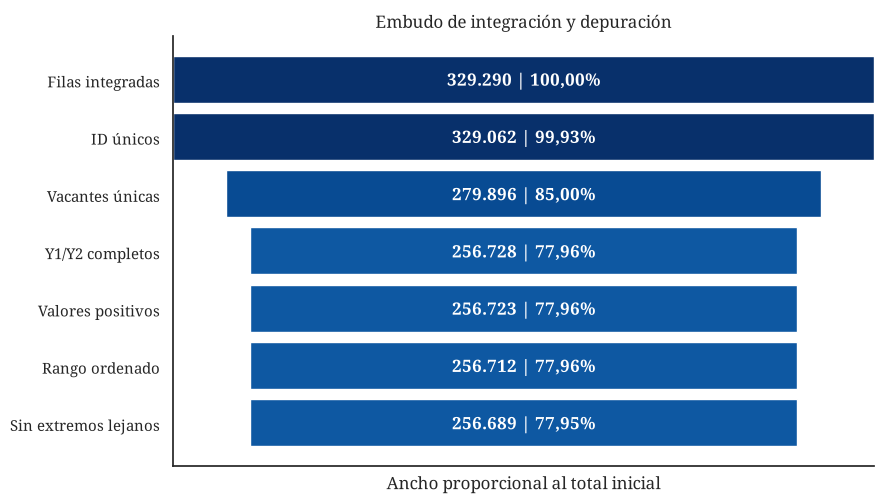

,registros,porcentaje_inicial,descartados
Filas integradas,329290,1.000000,NaN
ID únicos,329062,0.999308,228.0
Vacantes únicas,279896,0.849998,49166.0
Y1/Y2 completos,256728,0.779641,23168.0
Valores positivos,256723,0.779626,5.0
Rango ordenado,256712,0.779592,11.0
Sin extremos lejanos,256689,0.779523,23.0


In [7]:
flow=pd.Series({'Filas integradas':len(raw),'ID únicos':len(by_id),'Vacantes únicas':len(dedup),
 'Y1/Y2 completos':int(has_target.sum()),'Valores positivos':int(positive.sum()),
 'Rango ordenado':len(target),'Sin extremos lejanos':len(model_df)})
initial=flow.iloc[0]; left=(initial-flow.values)/2
fig,ax=plt.subplots(figsize=(9,5.2)); colors=plt.cm.Blues(.30+.70*flow.values/initial)
bars=ax.barh(flow.index,flow.values,left=left,color=colors,height=.82)
for bar,v in zip(bars,flow.values):
    count_label=f'{v:,.0f}'.replace(',','.')
    pct_label=f'{v/initial:.2%}'.replace('.',',')
    ax.text(initial/2,bar.get_y()+bar.get_height()/2,f'{count_label} | {pct_label}',
            ha='center',va='center',color='white',fontweight='bold')
ax.invert_yaxis(); ax.set_xlim(0,initial); ax.set(title='Embudo de integración y depuración',xlabel='Ancho proporcional al total inicial',ylabel='')
ax.tick_params(axis='x',bottom=False,labelbottom=False); clean_ax(ax); plt.tight_layout(); plt.show()
flow.to_frame('registros').assign(porcentaje_inicial=flow/initial,descartados=flow.shift(1)-flow)

## 6. Valores faltantes y variables excluidas

Calculamos nuevamente la información faltante después de depurar el objetivo. No descartamos una vacante únicamente porque le falte un predictor: los campos categóricos podrán incorporar una categoría de ausencia y `experience_years` tendrá una bandera específica. La falta de `work_mode` es principalmente estructural, pues este código solo aplica cuando `has_remote=True`; ambos campos se combinarán en una sola modalidad. Excluimos `expired` porque se conoce después de la publicación, `language` por su baja variabilidad y todos los campos salariales utilizados para construir Y1/Y2 para evitar fuga de información.

In [8]:
original_columns=[c for c in raw.columns if not c.startswith('_')]
missing_final=model_df[original_columns].isna().mean().mul(100).sort_values(ascending=False).rename('% nulo')
display(missing_final[missing_final.gt(0)].round(3).to_frame())
leakage_columns=[c for c in original_columns if c.startswith('salary_')]
excluded_predictors=sorted(set(leakage_columns+['expired','language']))
pd.Series({'columnas_sin_nulos':int(missing_final.eq(0).sum()),
           'columnas_con_nulos':int(missing_final.gt(0).sum()),
           'predictores_excluidos':', '.join(excluded_predictors)})

,% nulo
work_mode,82.073
salary_max,79.096
salary_min,77.231
expired,6.142
countries,2.261
regions,1.868
experience_level,0.165
experience_years,0.024
salary_min_est,0.012
salary_max_est,0.012


columnas_sin_nulos                                                      16
columnas_con_nulos                                                      12
predictores_excluidos    expired, language, salary_currency, salary_max...
dtype: object

## 7. Procedencia y comportamiento del salario objetivo

Comparamos la cantidad y la distribución salarial de los rangos reportados, híbridos y estimados. Esta revisión permite medir cuánto depende la muestra de las estimaciones de Foorilla y evita tratarlas como si fueran salarios publicados por las empresas. A partir de este resultado planteamos un experimento principal con rangos completamente reportados y un análisis ampliado que conserve las demás procedencias por separado.

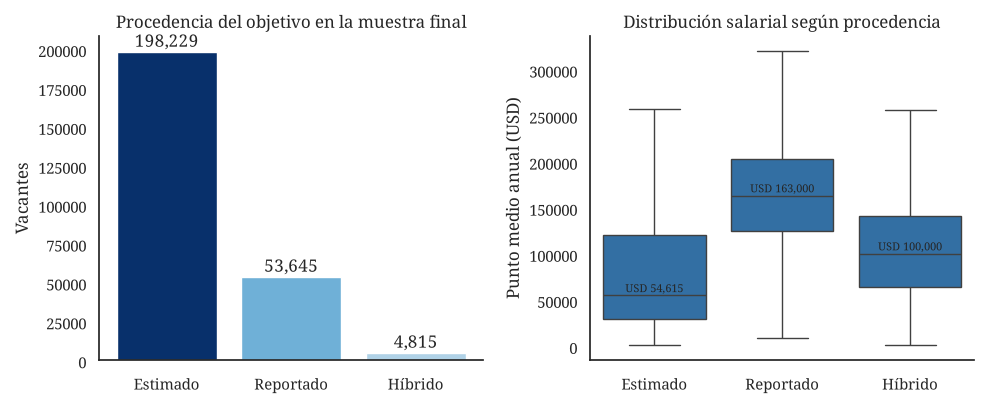

,n,mediana
target_source,,
Estimado,198229,54615.0
Reportado,53645,163000.0
Híbrido,4815,100000.0


In [9]:
source_order=model_df.target_source.value_counts().index.tolist()
source_stats=model_df.groupby('target_source').salary_midpoint_usd.agg(n='size',mediana='median').sort_values('n',ascending=False)
fig,axs=plt.subplots(1,2,figsize=(10,4.2))
colors=plt.cm.Blues(.30+.70*source_stats.n/source_stats.n.max())
bars=axs[0].bar(source_stats.index,source_stats.n,color=colors)
for b,v in zip(bars,source_stats.n): axs[0].text(b.get_x()+b.get_width()/2,v,f'{v:,.0f}',ha='center',va='bottom')
axs[0].set(title='Procedencia del objetivo en la muestra final',xlabel='',ylabel='Vacantes'); clean_ax(axs[0])
sns.boxplot(data=model_df,x='target_source',y='salary_midpoint_usd',order=source_stats.index,
            showfliers=False,color=BLUE,ax=axs[1])
for i,s in enumerate(source_stats.index): axs[1].text(i,source_stats.loc[s,'mediana'],f"USD {source_stats.loc[s,'mediana']:,.0f}",ha='center',va='bottom',fontsize=8)
axs[1].set(title='Distribución salarial según procedencia',xlabel='',ylabel='Punto medio anual (USD)'); clean_ax(axs[1])
plt.tight_layout(); plt.show(); source_stats

## 8. Posiciones más demandadas y evolución de las publicaciones

Para describir la demanda utilizamos todas las vacantes deduplicadas, incluso aquellas que no tienen salario. De esta forma, la frecuencia de los cargos no depende de que la empresa haya publicado la remuneración. Revisamos los títulos más comunes y la evolución mensual de las ofertas; el último mes se interpreta con cautela porque corresponde a un corte incompleto. El análisis detallado de `topics` y `tags` se realiza más adelante.

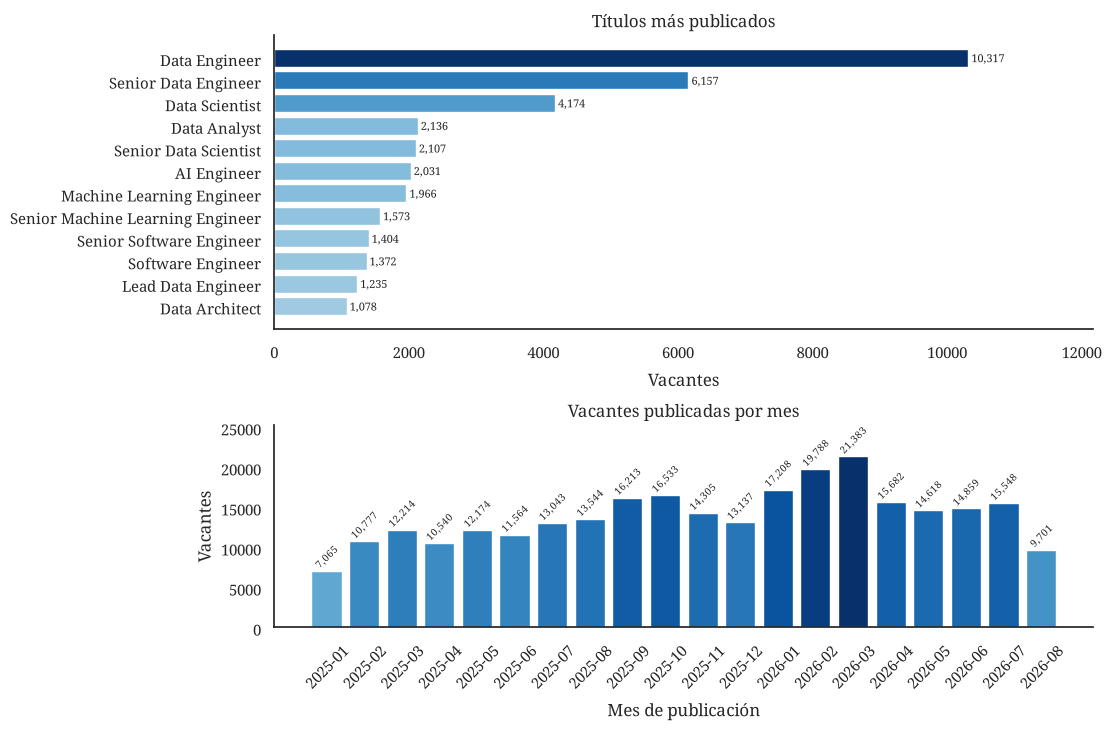

,titulo,vacantes
0,Data Engineer,10317
1,Senior Data Engineer,6157
2,Data Scientist,4174
3,Data Analyst,2136
4,Senior Data Scientist,2107
5,AI Engineer,2031
6,Machine Learning Engineer,1966
7,Senior Machine Learning Engineer,1573
8,Senior Software Engineer,1404
9,Software Engineer,1372


,vacantes
topic,
"Data, AI, and Machine Learning",279896
Data Engineering,168809
Big Data,92634
Finance & Fintech,83938
Financial Platforms and Digital Banking,79221
MLOps,70679
Software Engineering & Development,45408
Data Science,41942


In [10]:
top_titles=dedup.title.value_counts().head(12)
topics=(dedup[['id','topics']].assign(topic=dedup.topics.fillna('').str.split('|')).explode('topic'))
topics['topic']=topics.topic.str.strip(); top_topics=topics.loc[topics.topic.ne(''),'topic'].value_counts().head(8)
monthly=dedup.set_index('published').resample('MS').size()
fig,axs=plt.subplots(2,1,figsize=(11,7.2),height_ratios=[1.45,1],layout='constrained')
s=top_titles.sort_values(); colors=plt.cm.Blues(.30+.70*s/s.max()); bars=axs[0].barh(s.index,s.values,color=colors)
for b,v in zip(bars,s.values): axs[0].text(v,b.get_y()+b.get_height()/2,f' {v:,.0f}',va='center',ha='left',fontsize=8)
axs[0].set(title='Títulos más publicados',xlabel='Vacantes',ylabel=''); axs[0].margins(x=.18); clean_ax(axs[0])
month_labels=monthly.index.strftime('%Y-%m')
month_colors=plt.cm.Blues(.30+.70*monthly/monthly.max())
bars=axs[1].bar(month_labels,monthly.values,color=month_colors)
for b,v in zip(bars,monthly.values): axs[1].text(b.get_x()+b.get_width()/2,v,f'{v:,.0f}',ha='center',va='bottom',fontsize=7,rotation=45)
axs[1].set(title='Vacantes publicadas por mes',xlabel='Mes de publicación',ylabel='Vacantes'); axs[1].margins(y=.18); clean_ax(axs[1]); axs[1].tick_params(axis='x',rotation=45)
plt.show()
display(pd.DataFrame({'titulo':top_titles.index,'vacantes':top_titles.values})); display(top_topics.to_frame('vacantes'))

## 9. Nivel salarial y amplitud de los intervalos

Utilizamos el punto medio únicamente como medida descriptiva del nivel salarial; los objetivos del proyecto continúan siendo Y1 y Y2. También estudiamos la amplitud (`Y2 - Y1`), ya que dos vacantes con el mismo punto medio pueden ofrecer rangos muy distintos. Un intervalo demasiado amplio reduce la utilidad de la estimación para comparar ofertas o preparar una negociación.

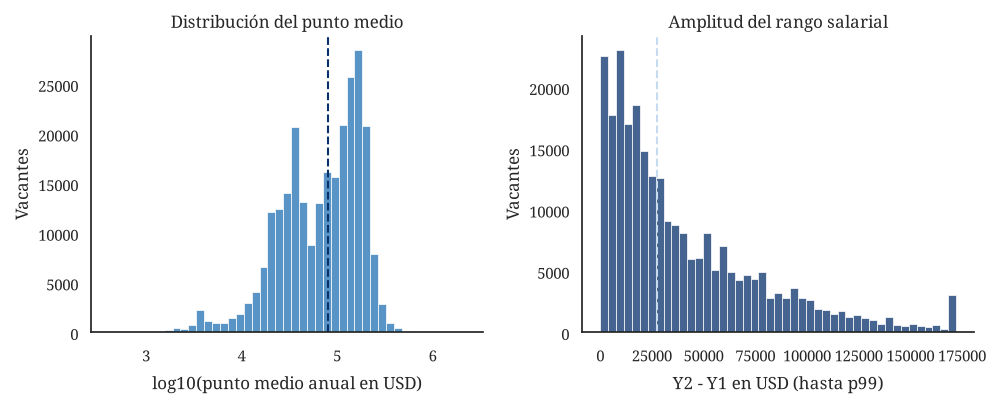

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
y_min_usd,256689.0,75785.924075,57877.076032,293.0,3107.00,25960.0,63997.0,115874.0,177000.0,240000.00,2190158.0
salary_midpoint_usd,256689.0,96130.404558,72101.986124,412.0,3815.00,33824.5,80870.5,148500.0,219850.0,296200.00,2190158.0
y_max_usd,256689.0,116474.885040,88714.196899,436.0,4438.88,41792.0,96260.0,179000.0,272600.0,361400.00,2190158.0
salary_width_usd,256689.0,40688.960964,40560.371182,0.0,0.00,11642.0,27243.0,59700.0,118200.0,172168.32,1120100.0


In [11]:
salary_stats=model_df[['y_min_usd','salary_midpoint_usd','y_max_usd','salary_width_usd']].describe(percentiles=[.01,.25,.5,.75,.95,.99]).T
fig,axs=plt.subplots(1,2,figsize=(10,4.2))
sns.histplot(np.log10(model_df.salary_midpoint_usd),bins=45,color=BLUE,ax=axs[0])
axs[0].axvline(np.log10(model_df.salary_midpoint_usd.median()),color=BLUE_DARK,linestyle='--')
axs[0].set(title='Distribución del punto medio',xlabel='log10(punto medio anual en USD)',ylabel='Vacantes'); clean_ax(axs[0])
width_cap=model_df.salary_width_usd.clip(upper=model_df.salary_width_usd.quantile(.99))
sns.histplot(width_cap,bins=45,color=BLUE_DARK,ax=axs[1])
axs[1].axvline(model_df.salary_width_usd.median(),color=BLUE_LIGHT,linestyle='--')
axs[1].set(title='Amplitud del rango salarial',xlabel='Y2 - Y1 en USD (hasta p99)',ylabel='Vacantes'); clean_ax(axs[1])
plt.tight_layout(); plt.show(); salary_stats

## 10. Experiencia, modalidad e idioma de la vacante

Analizamos `experience_level` como nivel categórico y `experience_years` como una medida numérica complementaria. Para obtener una sola modalidad combinamos `has_remote` con el diccionario de `work_mode`: `has_remote=False` corresponde a presencial; cuando es verdadero, los códigos 1, 2 y 3 representan híbrido, remoto y remoto en cualquier lugar. Si una vacante está marcada como remota pero no tiene código, la conservamos como remota sin asignarle un alcance adicional. El idioma permanece en la descripción de calidad, aunque no se propone como predictor inicial porque casi todas las publicaciones están en inglés.

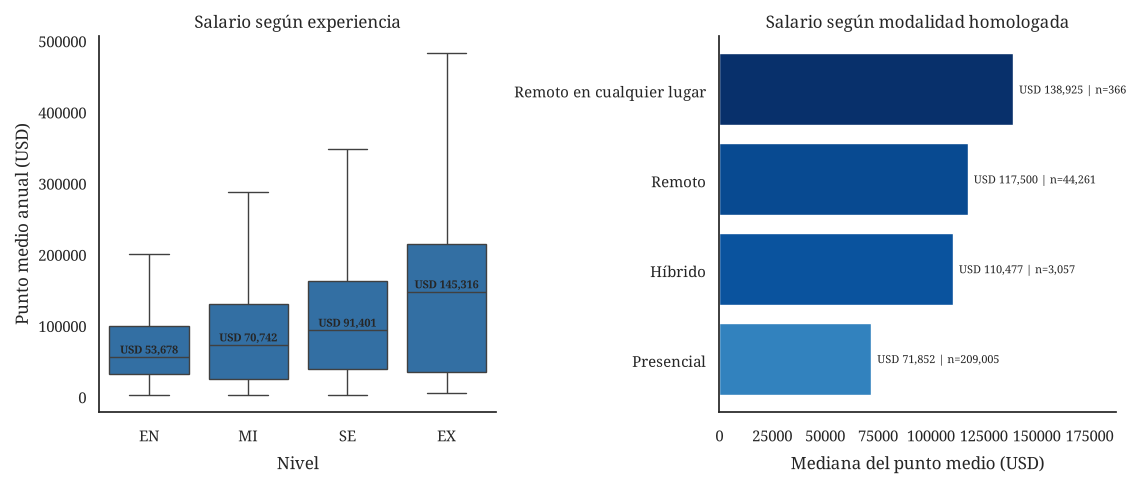

,n,mediana
experience_level,,
EN,18360,53678.0
MI,81218,70741.5
SE,151089,91401.0
EX,5598,145316.5


,n,mediana
modalidad,,
Remoto en cualquier lugar,366,138925.0
Remoto,44261,117500.0
Híbrido,3057,110477.0
Presencial,209005,71852.5


,vacantes,work_mode_faltante,porcentaje
modalidad_homologada,,,
Presencial,209005,209005,81.4
Remoto,44261,1667,17.2
Híbrido,3057,0,1.2
Remoto en cualquier lugar,366,0,0.1


,vacantes,hibrida_explicita_pct,remota_explicita_pct,global_explicita_pct
1,3057,36.5,6.9,0.0
2,42594,0.0,78.1,0.6
3,366,0.0,20.5,42.1


In [12]:
order=['EN','MI','SE','EX']; exp=model_df[model_df.experience_level.isin(order)].copy()
has_remote_flag=model_df.has_remote.fillna(False).astype(bool)
work_mode_code=pd.to_numeric(model_df.work_mode,errors='coerce')
modalidad_trabajo=pd.Series(np.select(
    [~has_remote_flag,
     has_remote_flag & work_mode_code.eq(1),
     has_remote_flag & work_mode_code.eq(3),
     has_remote_flag],
    ['Presencial','Híbrido','Remoto en cualquier lugar','Remoto'],default='Sin información'),
    index=model_df.index,name='modalidad_trabajo')
remote=model_df.assign(modalidad=modalidad_trabajo)
remote_stats=remote.groupby('modalidad').salary_midpoint_usd.agg(n='size',mediana='median').sort_values('mediana',ascending=False)
mode_text=(model_df.title.fillna('')+' '+model_df.location.fillna('')).str.lower()
mode_evidence=pd.DataFrame(index=[1,2,3])
mode_evidence['vacantes']=[int(work_mode_code.eq(i).sum()) for i in mode_evidence.index]
mode_evidence['hibrida_explicita_pct']=[100*mode_text[work_mode_code.eq(i)].str.contains(r'\bhybrid\b|h[ií]br',regex=True).mean() for i in mode_evidence.index]
mode_evidence['remota_explicita_pct']=[100*mode_text[work_mode_code.eq(i)].str.contains(r'\bremote\b|work.?from.?home|work.?at.?home|wfh',regex=True).mean() for i in mode_evidence.index]
mode_evidence['global_explicita_pct']=[100*mode_text[work_mode_code.eq(i)].str.contains(r'\bglobal\b|\bworldwide\b|anywhere',regex=True).mean() for i in mode_evidence.index]
fig,axs=plt.subplots(1,2,figsize=(11.5,5.0))
sns.boxplot(data=exp,x='experience_level',y='salary_midpoint_usd',order=order,showfliers=False,color=BLUE,ax=axs[0])
exp_med=exp.groupby('experience_level').salary_midpoint_usd.median().reindex(order)
for i,v in enumerate(exp_med): axs[0].text(i,v,f'USD {v:,.0f}',ha='center',va='bottom',fontsize=8,fontweight='bold')
axs[0].set(title='Salario según experiencia',xlabel='Nivel',ylabel='Punto medio anual (USD)'); clean_ax(axs[0])
remote_plot=remote_stats.sort_values('mediana')
colors=plt.cm.Blues(.35+.65*remote_plot.mediana/remote_plot.mediana.max()); bars=axs[1].barh(remote_plot.index,remote_plot.mediana,color=colors)
for b,(idx,row) in zip(bars,remote_plot.iterrows()): axs[1].text(row.mediana,b.get_y()+b.get_height()/2,f'  USD {row.mediana:,.0f} | n={row.n:,.0f}',ha='left',va='center',fontsize=8)
axs[1].set_xlim(0,remote_plot.mediana.max()*1.35)
axs[1].set(title='Salario según modalidad homologada',xlabel='Mediana del punto medio (USD)',ylabel=''); clean_ax(axs[1])
plt.tight_layout(); plt.show()
display(exp.groupby('experience_level').salary_midpoint_usd.agg(n='size',mediana='median').reindex(order))
mode_audit=(pd.DataFrame({'has_remote':has_remote_flag,'work_mode':work_mode_code,
                          'modalidad_homologada':modalidad_trabajo})
              .groupby('modalidad_homologada',dropna=False)
              .agg(vacantes=('modalidad_homologada','size'),
                   work_mode_faltante=('work_mode',lambda s:s.isna().sum())))
mode_audit['porcentaje']=100*mode_audit.vacantes/len(model_df)
display(remote_stats); display(mode_audit.sort_values('vacantes',ascending=False).round(1)); display(mode_evidence.round(1))

In [13]:
experience_numeric=pd.to_numeric(model_df.experience_years,errors='coerce')
experience_valid=experience_numeric.between(0,50)
experience_years_clean=experience_numeric.where(experience_valid)
experience_years_missing=experience_years_clean.isna()
language_raw=model_df.language.fillna('sin_informacion')
language_counts=language_raw.value_counts()
language_grouped=language_raw.where(language_raw.map(language_counts).ge(1000),'otros')
experience_groups=pd.cut(experience_years_clean,
                         bins=[-0.01,2,5,10,15,np.inf],
                         labels=['0-2','3-5','6-10','11-15','16+'])
experience_years_stats=(model_df.assign(grupo_experiencia=experience_groups)
    .groupby('grupo_experiencia',observed=False).salary_midpoint_usd
    .agg(n='size',mediana='median'))
language_stats=(model_df.groupby('language',dropna=False).salary_midpoint_usd
    .agg(n='size',mediana='median').sort_values('n',ascending=False))
display(pd.Series({'experience_years_nulos':int(experience_numeric.isna().sum()),
                   'experience_years_fuera_0_50':int((experience_numeric.notna() & ~experience_valid).sum()),
                   'experience_years_mediana':experience_years_clean.median(),
                   'idiomas_unicos':model_df.language.nunique(dropna=True),
                   'language_nulos':int(model_df.language.isna().sum())}))
display(experience_years_stats); display(language_stats.head(12)); display(language_grouped.value_counts())

experience_years_nulos         62.0
experience_years_fuera_0_50     1.0
experience_years_mediana        5.0
idiomas_unicos                 28.0
language_nulos                  5.0
dtype: float64

,n,mediana
grupo_experiencia,,
0-2,39025,70000.0
3-5,145155,81982.5
6-10,64988,98045.0
11-15,6969,46477.0
16+,489,40903.5


,n,mediana
language,,
en,249700,83596.75
fr,1689,57091.00
pt,1598,10750.00
es,1433,39770.50
zh,914,28438.50
de,799,74492.00
it,199,44582.50
nl,129,74500.50
ja,93,44368.00


language
en       249700
otros      2269
fr         1689
pt         1598
es         1433
Name: count, dtype: int64

## 11. Cobertura geográfica y comparación con América Latina

Separamos las ubicaciones que contienen varios países sin perder el identificador original de la vacante. Conservamos el país informado por Foorilla y no eliminamos observaciones únicamente por su ubicación; cuando una asignación es ambigua, la tratamos como una limitación de calidad. Comparamos los mercados con mayor cobertura y presentamos por separado América Latina, que constituye una región central para la pregunta de negocio.

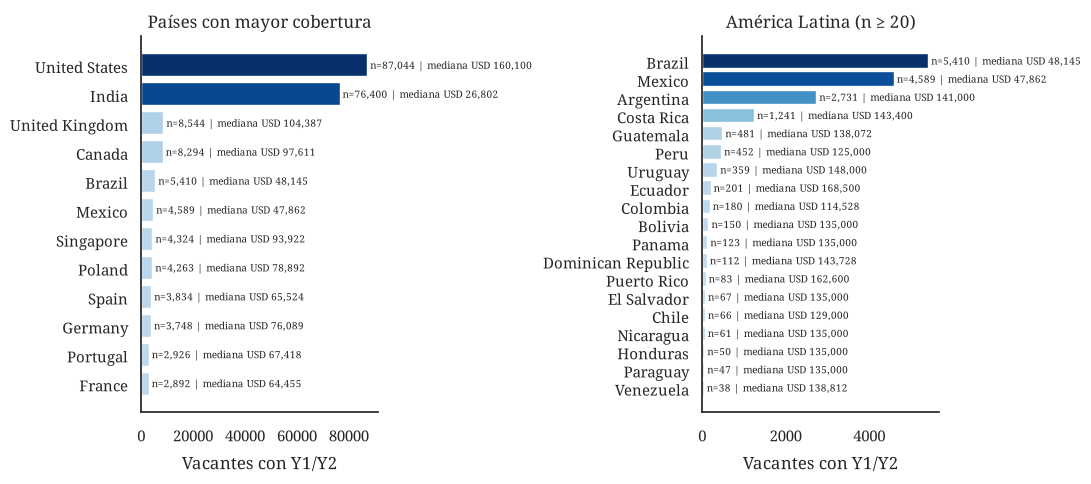

,n,mediana
country,,
United States,87044,160100.00
India,76400,26802.00
United Kingdom,8544,104386.75
Canada,8294,97611.00
Brazil,5410,48145.00
Mexico,4589,47862.00
Singapore,4324,93922.50
Poland,4263,78892.50
Spain,3834,65524.25


,n,mediana
country,,
Brazil,5410,48145.00
Mexico,4589,47862.00
Argentina,2731,141000.00
Costa Rica,1241,143400.00
Guatemala,481,138071.50
Peru,452,125000.00
Uruguay,359,148000.00
Ecuador,201,168500.00
Colombia,180,114528.25


In [14]:
geo=(model_df[['id','countries','salary_midpoint_usd','target_source']]
     .assign(country=model_df.countries.fillna('').str.split('|')).explode('country'))
geo['country']=geo.country.str.strip(); geo=geo[geo.country.ne('')]
country_stats=geo.groupby('country').salary_midpoint_usd.agg(n='size',mediana='median')
top_country=country_stats.sort_values('n',ascending=False).head(12)
latam_names=['Argentina','Bolivia','Brazil','Chile','Colombia','Costa Rica','Cuba','Dominican Republic','Ecuador','El Salvador','Guatemala','Honduras','Mexico','Nicaragua','Panama','Paraguay','Peru','Puerto Rico','Uruguay','Venezuela']
latam=(country_stats.loc[country_stats.index.intersection(latam_names)]
       .drop(index='Cuba',errors='ignore').query('n>=20').sort_values('n',ascending=False))
fig,axs=plt.subplots(1,2,figsize=(11,5))
for ax,stats,title in [(axs[0],top_country,'Países con mayor cobertura'),(axs[1],latam,'América Latina (n ≥ 20)')]:
    colors=plt.cm.Blues(.25+.75*stats.n/stats.n.max()); bars=ax.barh(stats.index,stats.n,color=colors)
    ax.invert_yaxis()
    for b,(idx,row) in zip(bars,stats.iterrows()): ax.text(row.n,b.get_y()+b.get_height()/2,f' n={row.n:,.0f} | mediana USD {row.mediana:,.0f}',va='center',ha='left',fontsize=7.5)
    ax.set(title=title,xlabel='Vacantes con Y1/Y2',ylabel=''); clean_ax(ax)
plt.tight_layout(); plt.show(); display(top_country); display(latam)

In [15]:
ambiguous=geo[geo.country.eq('Cuba')]
display(pd.Series({'filas_asociadas_con_cuba':ambiguous.id.nunique(),
 'mediana_usd':ambiguous.salary_midpoint_usd.median()}))
display(model_df[model_df.id.isin(ambiguous.id)][['id','company','title','location','countries','target_source']].head(15))

filas_asociadas_con_cuba       150.0
mediana_usd                 219750.0
dtype: float64

,id,company,title,location,countries,target_source
202328,1067095,AgileEngine,AI Consultant (Lead) ID35730,"JOSE MARTI, Argentina",Argentina|Cuba,Estimado
202180,1066661,AgileEngine,Java Engineer (Senior) ID38560,"JOSE MARTI, Argentina",Argentina|Cuba,Estimado
193250,1158667,AgileEngine,Database Engineer (Senior/Lead) ID41867,"JOSE MARTI, Argentina",Argentina|Cuba,Estimado
78512,2336672,AgileEngine,Software Engineer (Go) ID50984,"JOSE MARTI, Argentina",Argentina|Cuba,Estimado
83441,2282867,AgileEngine,Backend Software Engineer (Middle) ID51653,"JOSE MARTI, Argentina",Argentina|Cuba,Estimado
12462,3265248,Bambu Lab,Data Analyst - US,Santa Clara,Cuba,Estimado
7241,3335038,Bambu Lab,Database Administrator (DBA / DBRE) - Cloud Da...,Santa Clara,Cuba,Reportado
327655,3473997,LG Electronics,Backend/ML Engineer,"Santa Clara, CA",Cuba,Reportado
13605,3250893,XPeng Motors,Senior Machine Learning Data Curation Engineer,"Santa Clara, CA",Cuba,Reportado
616,3438600,XPeng Motors,Senior Machine Learning Engineer - LLM Quantiz...,"Santa Clara, CA",Cuba,Reportado


## 12. Áreas, habilidades y familias de cargos

Interpretamos `topics` como áreas generales y no como nombres de cargos, ya que una misma vacante puede pertenecer a varias. El campo `tags` reúne herramientas, conocimientos y otros atributos, por lo que no resulta conveniente tratar cada combinación como una categoría independiente. Construimos un vocabulario controlado que transforma las etiquetas reconocidas en columnas binarias y permite relacionar cada área con sus habilidades más frecuentes. Las familias de cargos se derivan de `title`, que contiene el nombre específico de la posición.

In [16]:
TOOL_ALIASES={
 'Python':['python'],'SQL':['sql'],'AWS':['aws','amazon web services'],
 'Azure':['azure','microsoft azure'],'GCP':['gcp','google cloud','google cloud platform'],
 'Spark':['spark','apache spark','pyspark'],'Databricks':['databricks'],
 'Snowflake':['snowflake'],'Docker':['docker'],'Kubernetes':['kubernetes'],
 'Airflow':['airflow','apache airflow'],'dbt':['dbt'],'Kafka':['kafka','apache kafka'],
 'Tableau':['tableau'],'Power BI':['power bi'],'TensorFlow':['tensorflow'],
 'PyTorch':['pytorch'],'scikit-learn':['scikit-learn','sklearn'],'Java':['java'],'R':['r'],
 'CI/CD':['ci/cd']}
KNOWLEDGE_ALIASES={
 'Machine Learning':['machine learning'],'Deep Learning':['deep learning'],
 'NLP':['natural language processing'],'LLM':['large language models','llm'],
 'IA generativa':['generative ai','genai'],'Computer Vision':['computer vision'],
 'Estadística':['statistics','statistical analysis'],'Series de tiempo':['time series','time series analysis'],
 'ETL/ELT':['etl','elt'],'Modelado de datos':['data modeling'],'MLOps':['mlops'],
 'Business Intelligence':['business intelligence'],'Big Data':['big data']}

def slug(text): return re.sub(r'[^a-z0-9]+','_',text.lower()).strip('_')
alias_to_feature={}
feature_labels={}
feature_groups={}
for group,mapping in [('Herramienta',TOOL_ALIASES),('Conocimiento',KNOWLEDGE_ALIASES)]:
    for label,aliases in mapping.items():
        column=('tool_' if group=='Herramienta' else 'knowledge_')+slug(label)
        feature_labels[column]=label; feature_groups[column]=group
        for alias in aliases: alias_to_feature[alias.casefold()]=column

def extract_tag_features(value):
    return {alias_to_feature[token.strip().casefold()]
            for token in str(value).split('|')
            if token.strip().casefold() in alias_to_feature}

tag_feature_sets=model_df.tags.fillna('').map(extract_tag_features)
tag_features=pd.DataFrame({column:tag_feature_sets.map(lambda values,c=column:c in values)
                           for column in feature_labels},index=model_df.index,dtype=bool)

TOPIC_AREAS=['Data Engineering','Big Data','Finance & Fintech','MLOps',
             'Software Engineering & Development','Data Science',
             'Artificial Intelligence','Machine Learning']
topic_sets=model_df.topics.fillna('').map(lambda value:{token.strip() for token in str(value).split('|')})
topic_features=pd.DataFrame({'topic_'+slug(area):topic_sets.map(lambda values,a=area:a in values)
                             for area in TOPIC_AREAS},index=model_df.index,dtype=bool)

def role_family(value):
    if 'mlops' in value: return 'MLOps'
    if 'machine learning' in value and ('engineer' in value or 'developer' in value): return 'ML Engineer'
    if re.search(r'\b(ai|artificial intelligence|genai|generative ai)\b',value) and ('engineer' in value or 'developer' in value): return 'AI Engineer'
    if 'data engineer' in value or 'analytics engineer' in value: return 'Data Engineer'
    if 'data scientist' in value: return 'Data Scientist'
    if 'data analyst' in value or 'business intelligence analyst' in value or 'bi analyst' in value: return 'Data/BI Analyst'
    if 'data architect' in value: return 'Data Architect'
    if 'software engineer' in value or 'software developer' in value: return 'Software Engineer'
    return 'Otra familia'

role_family_series=norm_text(model_df.title).map(role_family).rename('role_family')
base_features=pd.DataFrame({'id':model_df.id,
                            'experience_level':model_df.experience_level.fillna('sin_informacion'),
                            'experience_years_clean':experience_years_clean,
                            'experience_years_missing':experience_years_missing,
                            'modalidad_trabajo':modalidad_trabajo,
                            'countries':model_df.countries.fillna('sin_informacion'),
                            'company':model_df.company.fillna('sin_informacion'),
                            'company_is_agency':model_df.company_is_agency.fillna(False).astype(bool)},index=model_df.index)
model_features=pd.concat([base_features,role_family_series,
                          topic_features.add_prefix(''),tag_features],axis=1)
feature_summary=pd.DataFrame([
 {'variable':column,'grupo':feature_groups[column],'etiqueta':feature_labels[column],
  'vacantes':int(tag_features[column].sum()),
  'cobertura_pct':100*tag_features[column].mean(),
  'mediana_usd':model_df.loc[tag_features[column],'salary_midpoint_usd'].median()}
 for column in tag_features.columns]).sort_values('vacantes',ascending=False)
display(pd.Series({'combinaciones_tags_unicas':model_df.tags.nunique(),
                   'columnas_herramientas':len(TOOL_ALIASES),
                   'columnas_conocimientos':len(KNOWLEDGE_ALIASES),
                   'columnas_topics':len(TOPIC_AREAS),
                   'familias_cargo':role_family_series.nunique()}))
display(feature_summary.head(20)); display(model_features.head())

combinaciones_tags_unicas    252151
columnas_herramientas            21
columnas_conocimientos           13
columnas_topics                   8
familias_cargo                    9
dtype: int64

,variable,grupo,etiqueta,vacantes,cobertura_pct,mediana_usd
0,tool_python,Herramienta,Python,170474,66.412663,80713.75
1,tool_sql,Herramienta,SQL,116322,45.316317,69939.50
2,tool_aws,Herramienta,AWS,68553,26.706637,76528.50
21,knowledge_machine_learning,Conocimiento,Machine Learning,63275,24.650452,103564.00
5,tool_spark,Herramienta,Spark,61329,23.892337,66366.50
20,tool_ci_cd,Herramienta,CI/CD,54083,21.069465,67640.00
30,knowledge_modelado_de_datos,Conocimiento,Modelado de datos,52562,20.476920,71453.75
3,tool_azure,Herramienta,Azure,50273,19.585179,64899.00
4,tool_gcp,Herramienta,GCP,45125,17.579639,74524.00
9,tool_kubernetes,Herramienta,Kubernetes,41996,16.360654,80347.75


,id,experience_level,experience_years_clean,experience_years_missing,modalidad_trabajo,countries,company,company_is_agency,role_family,topic_data_engineering,topic_big_data,topic_finance_fintech,topic_mlops,topic_software_engineering_development,topic_data_science,topic_artificial_intelligence,topic_machine_learning,tool_python,tool_sql,tool_aws,tool_azure,tool_gcp,tool_spark,tool_databricks,tool_snowflake,...,tool_kubernetes,tool_airflow,tool_dbt,tool_kafka,tool_tableau,tool_power_bi,tool_tensorflow,tool_pytorch,tool_scikit_learn,tool_java,tool_r,tool_ci_cd,knowledge_machine_learning,knowledge_deep_learning,knowledge_nlp,knowledge_llm,knowledge_ia_generativa,knowledge_computer_vision,knowledge_estad_stica,knowledge_series_de_tiempo,knowledge_etl_elt,knowledge_modelado_de_datos,knowledge_mlops,knowledge_business_intelligence,knowledge_big_data
43005,2822341,SE,5.0,False,Presencial,United States,Five Rivers Cattle Feeding,False,Otra familia,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
319323,6985,SE,10.0,False,Presencial,United States,Absolute Business Solutions Corp.,False,Data Engineer,True,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
41999,2834097,SE,5.0,False,Presencial,United States,Absolute Business Solutions Corp.,False,Data Engineer,True,False,False,False,False,False,False,False,True,True,False,False,False,True,True,False,...,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
106938,2066136,SE,5.0,False,Remoto,United States,Ad Hoc,False,Data Engineer,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
73069,2406937,SE,8.0,False,Remoto,United States,Ad Hoc,False,Data Engineer,True,True,False,False,False,False,False,False,True,False,True,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False


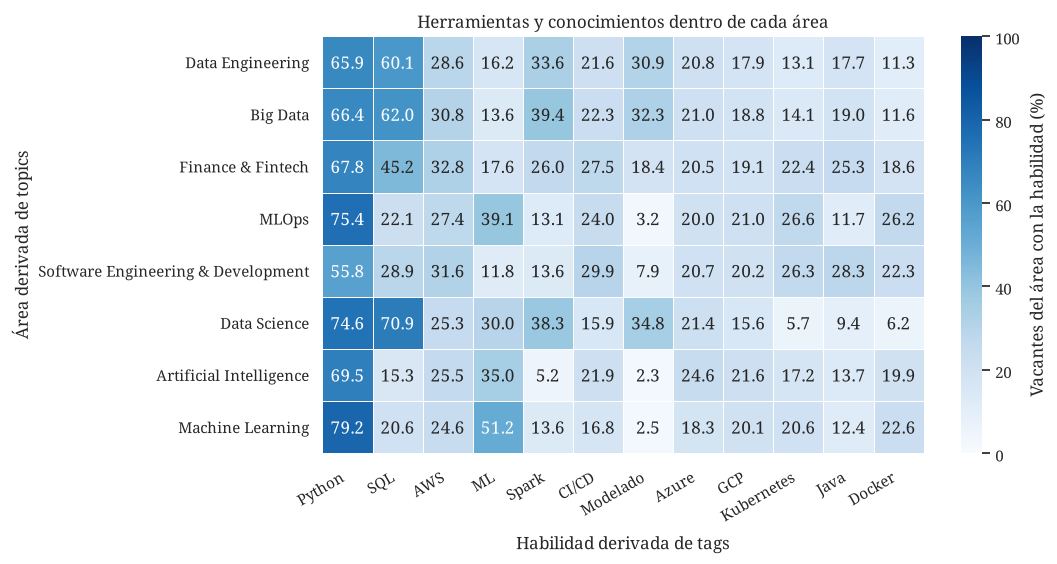

,Python,SQL,AWS,Machine Learning,Spark,CI/CD,Modelado de datos,Azure,GCP,Kubernetes,Java,Docker
Data Engineering,65.894994,60.100018,28.581397,16.240018,33.575194,21.556225,30.880263,20.835810,17.872096,13.085700,17.707337,11.308247
Big Data,66.406232,61.960345,30.803729,13.630355,39.386286,22.317951,32.281364,21.026791,18.844565,14.087100,18.972029,11.598017
Finance & Fintech,67.795235,45.158885,32.773846,17.580031,26.037756,27.484661,18.362354,20.526171,19.118513,22.391711,25.330002,18.638391
MLOps,75.394904,22.142569,27.427614,39.110263,13.068305,23.982869,3.232163,20.046240,20.986562,26.619185,11.671787,26.209540
Software Engineering & Development,55.764304,28.930096,31.594486,11.755520,13.629377,29.930462,7.861413,20.673417,20.234232,26.255947,28.324997,22.327681
Data Science,74.607089,70.944297,25.298455,29.963530,38.299268,15.944691,34.835883,21.360166,15.642956,5.725081,9.382625,6.163251
Artificial Intelligence,69.548846,15.328267,25.542548,34.962689,5.216677,21.859382,2.334497,24.577257,21.626617,17.231464,13.705758,19.921955
Machine Learning,79.221080,20.554826,24.596244,51.247972,13.569276,16.807047,2.542307,18.275249,20.122093,20.601190,12.433351,22.594854


In [17]:
top_skill_columns=feature_summary.head(12).variable.tolist()
matrix=pd.DataFrame(index=TOPIC_AREAS,columns=top_skill_columns,dtype=float)
for area in TOPIC_AREAS:
    members=topic_features['topic_'+slug(area)]
    matrix.loc[area]=tag_features.loc[members,top_skill_columns].mean().mul(100)
matrix=matrix.rename(columns=feature_labels)
matrix_plot=matrix.rename(columns={'Machine Learning':'ML','Modelado de datos':'Modelado'})
fig,ax=plt.subplots(figsize=(11,5.8))
sns.heatmap(matrix_plot,annot=True,fmt='.1f',cmap='Blues',vmin=0,vmax=100,
            linewidths=.7,linecolor='white',cbar_kws={'label':'Vacantes del área con la habilidad (%)'},ax=ax)
ax.set(title='Herramientas y conocimientos dentro de cada área',xlabel='Habilidad derivada de tags',ylabel='Área derivada de topics')
ax.set_xticklabels(ax.get_xticklabels(),rotation=30,ha='right'); ax.tick_params(axis='y',rotation=0)
plt.tight_layout(); plt.show(); matrix

## 13. Empresa publicadora y condición de agencia

El campo `company` identifica a la empresa que publica la vacante y no contiene información sobre su tamaño. Aunque presenta una cardinalidad alta, lo conservamos porque puede aportar diferencias propias del empleador. `company_is_agency` permite distinguir entre agencias de reclutamiento y empleadores directos. La comparación es descriptiva; durante el modelado, cualquier codificación de la empresa deberá aprenderse exclusivamente con los datos de entrenamiento para evitar memorizar información de validación o prueba.

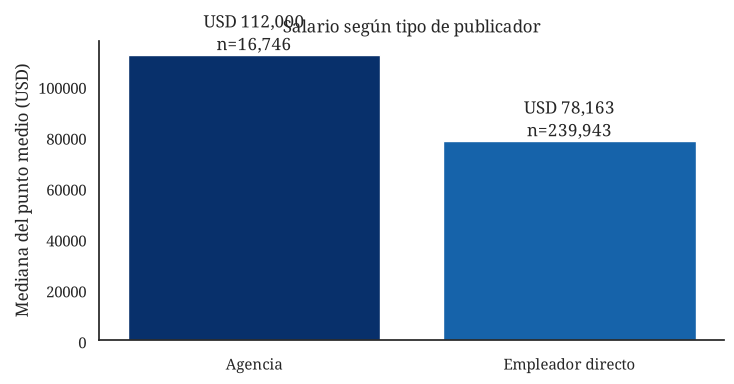

empresas_unicas       14282
Agencia               16746
Empleador directo    239943
dtype: int64

In [18]:
agency=model_df.assign(tipo=np.where(model_df.company_is_agency.fillna(False),'Agencia','Empleador directo'))
agency_stats=agency.groupby('tipo').salary_midpoint_usd.agg(n='size',mediana='median').sort_values('mediana',ascending=False)
fig,ax=plt.subplots(figsize=(7.5,4)); colors=plt.cm.Blues(.35+.65*agency_stats.mediana/agency_stats.mediana.max())
bars=ax.bar(agency_stats.index,agency_stats.mediana,color=colors)
for b,(idx,row) in zip(bars,agency_stats.iterrows()): ax.text(b.get_x()+b.get_width()/2,row.mediana,f'USD {row.mediana:,.0f}\nn={row.n:,.0f}',ha='center',va='bottom')
ax.set(title='Salario según tipo de publicador',xlabel='',ylabel='Mediana del punto medio (USD)'); clean_ax(ax); plt.tight_layout(); plt.show()
pd.Series({'empresas_unicas':model_df.company.nunique(),**agency_stats['n'].to_dict()})

## 14. Decisiones para el modelado y la evaluación

Los resultados permiten definir dos experimentos. El primero utilizará únicamente rangos reportados y servirá como evaluación principal; el segundo incorporará también rangos híbridos y estimados, pero mostrará sus métricas por procedencia. La partición será temporal y mantendrá las republicaciones de una misma vacante en un solo conjunto. Para el prototipo consideramos filtros por cargo, experiencia, modalidad, país y tipo de publicador, además de advertencias cuando la cobertura sea reducida o la ubicación resulte ambigua.

In [19]:
dated=model_df.dropna(subset=['published']).sort_values('published')
cut1=dated.published.quantile(.70); cut2=dated.published.quantile(.85)
split=np.select([dated.published<=cut1,dated.published<=cut2],['Entrenamiento','Validación'],default='Prueba')
split_counts=pd.Series(split).value_counts().reindex(['Entrenamiento','Validación','Prueba'])
model_plan=pd.DataFrame([
 ('Objetivos','Y1 y Y2 anuales en USD'),('Evaluación principal','Rangos completamente reportados'),
 ('Experimento ampliado','Reportados + híbridos + estimados, segmentando métricas'),
 ('Variables candidatas','Familia de cargo, topics, herramientas/conocimientos, experience_level, experience_years, modalidad homologada con has_remote/work_mode, país, company y company_is_agency'),
 ('Variables excluidas','Campos salariales, expired y language'),
 ('Partición','Temporal y agrupada por firma de vacante'),
 ('Métricas futuras','MAE de Y1/Y2, amplitud, cobertura y Y1>Y2')],columns=['Decisión','Aplicación'])
display(model_plan); display(pd.Series({'corte_70':cut1,'corte_85':cut2,**split_counts.to_dict()}))

,Decisión,Aplicación
0,Objetivos,Y1 y Y2 anuales en USD
1,Evaluación principal,Rangos completamente reportados
2,Experimento ampliado,"Reportados + híbridos + estimados, segmentando..."
3,Variables candidatas,"Familia de cargo, topics, herramientas/conocim..."
4,Variables excluidas,"Campos salariales, expired y language"
5,Partición,Temporal y agrupada por firma de vacante
6,Métricas futuras,"MAE de Y1/Y2, amplitud, cobertura y Y1>Y2"


corte_70                2026-03-10 00:00:00+00:00
corte_85         2026-05-25 20:15:05.600000+00:00
Entrenamiento                              179772
Validación                                  38413
Prueba                                      38504
dtype: object

In [20]:
top_language=language_raw.value_counts().index[0]
report_summary={
 'files':[{'archivo':row['archivo'],'filas':int(row['filas']),'id_unicos':int(row['id_unicos'])} for row in inventory],
 'fecha_min':str(by_id.published.min().date()),'fecha_max':str(by_id.published.max().date()),
 'variables_originales':int(len(original_columns)),
 'filas_integradas':int(len(raw)),'id_unicos':int(len(by_id)),
 'filas_repetidas_por_id':int(len(raw)-len(by_id)),
 'firmas_repetidas':int((group_sizes>1).sum()),
 'republicaciones_descartadas':int(len(by_id)-len(dedup)),
 'vacantes_deduplicadas':int(len(dedup)),
 'objetivo_incompleto':int((~has_target).sum()),
 'no_positivo':int((has_target & ~positive).sum()),
 'minimo_mayor_maximo':int((positive & ~ordered).sum()),
 'atipicos_extremos':int(len(outlier_audit)),'muestra_final':int(len(model_df)),
 'porcentaje_final':float(100*len(model_df)/len(raw)),
 'missing_pct':{c:float(missing_final.get(c,np.nan)) for c in ['work_mode','salary_max','salary_min','expired','countries','regions']},
 'remote_total':int(has_remote_flag.sum()),
 'remote_work_mode_informado':int((has_remote_flag & work_mode_code.notna()).sum()),
 'source_stats':{idx:{'n':int(row.n),'mediana':float(row.mediana)} for idx,row in source_stats.iterrows()},
 'salary':{'y1_mediana':float(model_df.y_min_usd.median()),
           'y2_mediana':float(model_df.y_max_usd.median()),
           'punto_medio_mediana':float(model_df.salary_midpoint_usd.median()),
           'amplitud_mediana':float(model_df.salary_width_usd.median()),
           'amplitud_p75':float(model_df.salary_width_usd.quantile(.75))},
 'top_titles':[{'titulo':str(idx),'n':int(value)} for idx,value in top_titles.head(7).items()],
 'experience':{idx:{'n':int(row.n),'mediana':float(row.mediana)} for idx,row in
               exp.groupby('experience_level').salary_midpoint_usd.agg(n='size',mediana='median').reindex(order).iterrows()},
 'experience_years_missing':int(experience_years_missing.sum()),
 'experience_years_invalid':int((experience_numeric.notna() & ~experience_valid).sum()),
 'modalidad':{idx:{'n':int(row.n),'mediana':float(row.mediana)} for idx,row in remote_stats.iterrows()},
 'top_language':str(top_language),'top_language_n':int((language_raw==top_language).sum()),
 'top_language_pct':float(100*(language_raw==top_language).mean()),
 'tag_top':[{'nombre':str(row.etiqueta),'n':int(row.vacantes),'pct':float(row.cobertura_pct)}
            for _,row in feature_summary.head(5).iterrows()],
 'topics_areas':int(len(TOPIC_AREAS)),'tools_columns':int(len(TOOL_ALIASES)),
 'knowledge_columns':int(len(KNOWLEDGE_ALIASES)),'tag_combinations':int(model_df.tags.nunique()),
 'country_top':{idx:{'n':int(row.n),'mediana':float(row.mediana)} for idx,row in top_country.iterrows()},
 'company_unique':int(model_df.company.nunique()),
 'agency':{idx:{'n':int(row.n),'mediana':float(row.mediana)} for idx,row in agency_stats.iterrows()},
 'split':{idx:int(value) for idx,value in split_counts.items()}}
display({'application/json':report_summary},raw=True)

## 15. Conclusiones del análisis exploratorio

El conjunto permite desarrollar un prototipo supervisado para estimar el salario mínimo y máximo de una vacante. Su principal limitación es que la mayoría de los rangos disponibles proviene de estimaciones de Foorilla, por lo que la procedencia deberá permanecer visible durante el entrenamiento, la evaluación y la presentación de resultados.

Como variables candidatas conservamos el cargo, las áreas, las habilidades, `experience_level`, `experience_years`, la modalidad homologada, la geografía, `company` y `company_is_agency`. Excluimos los campos salariales que originan Y1/Y2, el estado posterior `expired` y el idioma por su baja variabilidad. La siguiente fase deberá comparar los dos experimentos mediante una validación temporal y reportar resultados separados cuando la cobertura de un mercado o una categoría sea insuficiente.